# The Problem
This project is a mock case study.

An indie video-game studio wants to make a new game. They want to know what they can do to make their game popular.
They want to rely on data to make informed decisions. 

# Data
The database used in this analysis is the statistics of the games in the Steam store. Steam is a popular games-hosting platform for PC, Mac and Linux. This dataset contains more than 100 000 games.

In [1]:
# Impoting packages
import numpy as np
import pandas as pd

In [2]:
# Reading the data
df = pd.read_csv('/kaggle/input/steam-games-dataset/games.csv')

In [3]:
# Looking at the first few lines of data
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
20200,Galactic Bowling,"Oct 21, 2008",0 - 20000,0,0,19.99,0,0,Galactic Bowling is an exaggerated and stylize...,['English'],...,0,0,0,Perpetual FX Creative,Perpetual FX Creative,"Single-player,Multi-player,Steam Achievements,...","Casual,Indie,Sports","Indie,Casual,Sports,Bowling",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
655370,Train Bandit,"Oct 12, 2017",0 - 20000,0,0,0.99,0,0,THE LAW!! Looks to be a showdown atop a train....,"['English', 'French', 'Italian', 'German', 'Sp...",...,0,0,0,Rusty Moyher,Wild Rooster,"Single-player,Steam Achievements,Full controll...","Action,Indie","Indie,Action,Pixel Graphics,2D,Retro,Arcade,Sc...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1732930,Jolt Project,"Nov 17, 2021",0 - 20000,0,0,4.99,0,0,Jolt Project: The army now has a new robotics ...,"['English', 'Portuguese - Brazil']",...,0,0,0,Campião Games,Campião Games,Single-player,"Action,Adventure,Indie,Strategy",NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1355720,Henosis™,"Jul 23, 2020",0 - 20000,0,0,5.99,0,0,HENOSIS™ is a mysterious 2D Platform Puzzler w...,"['English', 'French', 'Italian', 'German', 'Sp...",...,0,0,0,Odd Critter Games,Odd Critter Games,"Single-player,Full controller support","Adventure,Casual,Indie","2D Platformer,Atmospheric,Surreal,Mystery,Puzz...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1139950,Two Weeks in Painland,"Feb 3, 2020",0 - 20000,0,0,0.00,0,0,ABOUT THE GAME Play as a hacker who has arrang...,"['English', 'Spanish - Spain']",...,0,0,0,Unusual Games,Unusual Games,"Single-player,Steam Achievements","Adventure,Indie","Indie,Adventure,Nudity,Violent,Sexual Content,...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...


It seems that there is an error with the column names. The first few column names do not correspond to the data in the column. This can be seen in the column named `Name` which is populated by dates. These dates are the actual release dates of the games. The problem comes from the column `DiscountDLC count`. This name should be split in two: `Discount` and `DLC count`. This error probably stems from a missing comma in the file.

I will have to rename the columns.

In [4]:
# A look at the column names (with error)
df.keys()

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'DiscountDLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'],
      dtype='object')

I just need to copy and paste the array and modify `'DiscountDLC count'` to `'Discount', 'DLC count'`. I also remove the name `'AppID'` because this column will be used as the index column.

In [5]:
# Remane the columns to with the correct names
df.columns = ['Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']

In [6]:
# Taking a look at the new array
df.head()

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
20200,Galactic Bowling,"Oct 21, 2008",0 - 20000,0,0,19.99,0,0,Galactic Bowling is an exaggerated and stylize...,['English'],...,0,0,0,Perpetual FX Creative,Perpetual FX Creative,"Single-player,Multi-player,Steam Achievements,...","Casual,Indie,Sports","Indie,Casual,Sports,Bowling",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
655370,Train Bandit,"Oct 12, 2017",0 - 20000,0,0,0.99,0,0,THE LAW!! Looks to be a showdown atop a train....,"['English', 'French', 'Italian', 'German', 'Sp...",...,0,0,0,Rusty Moyher,Wild Rooster,"Single-player,Steam Achievements,Full controll...","Action,Indie","Indie,Action,Pixel Graphics,2D,Retro,Arcade,Sc...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1732930,Jolt Project,"Nov 17, 2021",0 - 20000,0,0,4.99,0,0,Jolt Project: The army now has a new robotics ...,"['English', 'Portuguese - Brazil']",...,0,0,0,Campião Games,Campião Games,Single-player,"Action,Adventure,Indie,Strategy",NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1355720,Henosis™,"Jul 23, 2020",0 - 20000,0,0,5.99,0,0,HENOSIS™ is a mysterious 2D Platform Puzzler w...,"['English', 'French', 'Italian', 'German', 'Sp...",...,0,0,0,Odd Critter Games,Odd Critter Games,"Single-player,Full controller support","Adventure,Casual,Indie","2D Platformer,Atmospheric,Surreal,Mystery,Puzz...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1139950,Two Weeks in Painland,"Feb 3, 2020",0 - 20000,0,0,0.00,0,0,ABOUT THE GAME Play as a hacker who has arrang...,"['English', 'Spanish - Spain']",...,0,0,0,Unusual Games,Unusual Games,"Single-player,Steam Achievements","Adventure,Indie","Indie,Adventure,Nudity,Violent,Sexual Content,...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...


The indie studio  wants to know how they can make their game popular. In our dataset, this is shown by the `Estimated owners` column.

In [7]:
# Find out the different categories of number of owners
df['Estimated owners'].value_counts()

Estimated owners
0 - 20000                70206
0 - 0                    22091
20000 - 50000             8277
50000 - 100000            4068
100000 - 200000           2664
200000 - 500000           2206
500000 - 1000000           921
1000000 - 2000000          525
2000000 - 5000000          336
5000000 - 10000000          93
10000000 - 20000000         38
20000000 - 50000000         21
50000000 - 100000000         5
100000000 - 200000000        1
Name: count, dtype: int64

There is a category that is `0 - 0`. This is interesting. Is it really that nobody bought these games? Are they real games?
Let's look at a few of them.

In [8]:
# Looking at the '0 - 0' owners to see what they are
df[df['Estimated owners'] == '0 - 0'].head(10)

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
1959480,Eternal Edge+ Prologue,"May 5, 2022",0 - 0,0,0,0.00,0,0,Eternal Edge + Prologue is a casual Action Adv...,"['English', 'French', 'German', 'Spanish - Spa...",...,0,0,0,"Righteous Weasel Games,Ignatios Prouctions LLC","Sedoc LLC,GrabTheGames","Single-player,Full controller support","Action,Adventure,RPG",NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1662060,Moon Farming - Prologue,"Jan 6, 2022",0 - 0,0,0,0.00,0,0,/ / Tired from the same farming games on Earth...,"['English', 'French', 'Italian', 'German', 'Sp...",...,0,0,0,SimulaM,PlayWay S.A,Single-player,"Adventure,Casual,Indie,Simulation,Strategy",NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1943590,溪风谷之战 Playtest,"Mar 24, 2022",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995240,Deer Journey,"Jul 21, 2022",0 - 0,0,0,5.39,0,0,Deer Journey is a third person walking simulat...,"['English', 'Spanish - Spain', 'French', 'Ital...",...,0,0,0,Pablo Picazo,Pablo Picazo,"Single-player,Full controller support","Adventure,Indie",NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1966960,Burial Stone Playtest,"Apr 13, 2022",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,NaN
1755120,Ghosts of War: Battle Royale WW2 Shooting games,"Oct 26, 2021",0 - 0,0,0,0.00,0,0,Second World War shooter with Battle Royale mo...,"['English', 'French', 'Italian', 'German', 'Sp...",...,0,0,0,XDEVS LTD,XDEVS LTD,"Multi-player,PvP,Online PvP,Cross-Platform Mul...","Action,Adventure,Free to Play,Massively Multip...",NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
2010700,Hunter Survivors,"Jul 21, 2022",0 - 0,0,0,2.39,0,0,"Hunter Survivors is a survival roguelite, wher...","['English', 'Portuguese - Brazil']",...,0,0,0,LuCapy Studio,LuCapy Studio,"Single-player,Steam Achievements,Full controll...","Action,Adventure,Casual,Indie,RPG",NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1688630,Emperial Knights Playtest,"Nov 14, 2021",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,NaN
2026860,Maria Blanchard Virtual Gallery,"Jul 1, 2022",0 - 0,0,0,0.00,0,0,Maria Blanchard (1881-1932). She was a Franco-...,['Spanish - Spain'],...,0,0,0,Virtual Video,Virtual Video,NaN,"Design & Illustration,Education",NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1478660,Slotracers VR Playtest,"Dec 17, 2020",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


These games include some playtests. Searching for the other games online, we see that some of them are removed for the Steam store. The other games are just really unpopular games.

Ideally, I would like to remove the playtests and the removed games while keeping the actual, available games. However, this would be difficult. As such, I will remove all the games that have estimated owners of `0 - 0`.

In [9]:
# Removing the games that had 0 estimated owners
df = df[df['Estimated owners'] != '0 - 0']

In [10]:
# Getting the categories of estimated owners
df['Estimated owners'].value_counts().index

Index(['0 - 20000', '20000 - 50000', '50000 - 100000', '100000 - 200000',
       '200000 - 500000', '500000 - 1000000', '1000000 - 2000000',
       '2000000 - 5000000', '5000000 - 10000000', '10000000 - 20000000',
       '20000000 - 50000000', '50000000 - 100000000', '100000000 - 200000000'],
      dtype='object', name='Estimated owners')

These numbers are pretty hard to read, let's change them to use the K and M notation.

In [11]:
# Dictionnary that maps the current categories to the optimized categories
number_to_reduced_number = {
    '0 - 20000': '0 - 20K',
    '20000 - 50000': '20K - 50K',
    '50000 - 100000': '50K - 100K',
    '100000 - 200000': '100K - 200K',
    '200000 - 500000': '200K - 500K',
    '500000 - 1000000': '500K - 1M',
    '1000000 - 2000000': '1M - 2M',
    '2000000 - 5000000': '2M - 5M',
    '5000000 - 10000000': '5M - 10M',
    '10000000 - 20000000': '10M - 20M',
    '20000000 - 50000000': '20M - 50M',
    '50000000 - 100000000': '50M - 100M',
    '100000000 - 200000000': '100M - 200M'}

In [12]:
# Rename the estimated owners categories to the optimized categories
df['Estimated owners'] = df['Estimated owners'].map(number_to_reduced_number)
df.head()

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
20200,Galactic Bowling,"Oct 21, 2008",0 - 20K,0,0,19.99,0,0,Galactic Bowling is an exaggerated and stylize...,['English'],...,0,0,0,Perpetual FX Creative,Perpetual FX Creative,"Single-player,Multi-player,Steam Achievements,...","Casual,Indie,Sports","Indie,Casual,Sports,Bowling",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
655370,Train Bandit,"Oct 12, 2017",0 - 20K,0,0,0.99,0,0,THE LAW!! Looks to be a showdown atop a train....,"['English', 'French', 'Italian', 'German', 'Sp...",...,0,0,0,Rusty Moyher,Wild Rooster,"Single-player,Steam Achievements,Full controll...","Action,Indie","Indie,Action,Pixel Graphics,2D,Retro,Arcade,Sc...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1732930,Jolt Project,"Nov 17, 2021",0 - 20K,0,0,4.99,0,0,Jolt Project: The army now has a new robotics ...,"['English', 'Portuguese - Brazil']",...,0,0,0,Campião Games,Campião Games,Single-player,"Action,Adventure,Indie,Strategy",NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1355720,Henosis™,"Jul 23, 2020",0 - 20K,0,0,5.99,0,0,HENOSIS™ is a mysterious 2D Platform Puzzler w...,"['English', 'French', 'Italian', 'German', 'Sp...",...,0,0,0,Odd Critter Games,Odd Critter Games,"Single-player,Full controller support","Adventure,Casual,Indie","2D Platformer,Atmospheric,Surreal,Mystery,Puzz...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1139950,Two Weeks in Painland,"Feb 3, 2020",0 - 20K,0,0,0.00,0,0,ABOUT THE GAME Play as a hacker who has arrang...,"['English', 'Spanish - Spain']",...,0,0,0,Unusual Games,Unusual Games,"Single-player,Steam Achievements","Adventure,Indie","Indie,Adventure,Nudity,Violent,Sexual Content,...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...


In [13]:
# The prefered order for the estimated owners categories
estimated_owners_order = ['0 - 20K', '20K - 50K', '50K - 100K', '100K - 200K', '200K - 500K', '500K - 1M',
                          '1M - 2M', '2M - 5M', '5M - 10M', '10M - 20M', '20M - 50M', '50M - 100M', '100M - 200M']

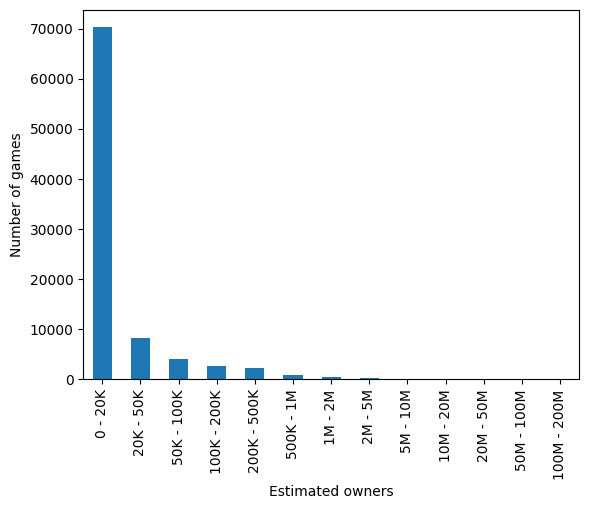

In [14]:
# Plotting the number of games for each estimated owners categories
df['Estimated owners'].value_counts().reindex(estimated_owners_order).plot.bar(ylabel='Number of games');

The number of games in each category quickly decays. This means that is it not easy to have a game that surpasses the 20000 downloads. Having a game that have even more owners is really difficult.

I want to note the 100M - 200M owners category only contains one game. Therefore, all the analysis from this category is only reliant on this game. This could bias the results. Therefore, every results that come from that category should be taken with a grain of salt.
With only five games, the 50M - 100M category also suffers from what is called the law of small numbers.

# Analysis



## Price

The price of a game can be an important factor when it comes to buying it. In this section, I will look at the price of the games as a function of popularity.

Let's start by looking at the statistics of free games.

In [15]:
# Calculate the fraction of free games (in percent)
df_percent_free = df[df['Price'] == 0]['Estimated owners'].value_counts() / df['Estimated owners'].value_counts() * 100

# The dataframe without free games
df_wo_free = df[df['Price'] != 0]

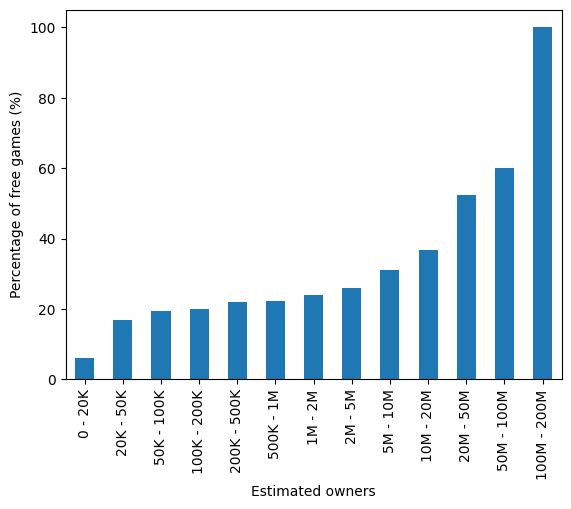

In [16]:
# Plot the fraction of games that are free
df_percent_free.plot.bar(ylabel='Percentage of free games (%)');

It is interesting to see that the fraction for free games increases for games that have more owners.
Free games are more downloaded because the game is more accessible as the player does not need to invest their money on the game.

One can ask how free games make money. They often times include in-game currency that is bought from real money, a process known as microtransactions.
The indie company that asked for this current analysis is clear that they do not want to profit from the sale of the game, and they do not want to include microtransactions on it.

Therefore, I will look at the statistics for two cases: all games, and wothout the free games.

In [17]:
# The dataframe that contains the average price per owners category 
df_average_price = pd.concat([df.groupby('Estimated owners')['Price'].mean().reindex(estimated_owners_order),
                                     df_wo_free.groupby('Estimated owners')['Price'].mean().reindex(estimated_owners_order)], axis=1)
df_average_price.columns = ['Average price', 'Average price excluding free games']

# The dataframe will contain a NaN because the 100M - 200M category only contains one games which is free
# it is impossible to calculate the mean without any values, let's replace it with 0
df_average_price.fillna(0, inplace=True)
df_average_price

,Average price,Average price excluding free games
Estimated owners,,
0 - 20K,7.739777,8.234260
20K - 50K,7.903591,9.497390
50K - 100K,9.096731,11.292493
100K - 200K,10.204351,12.768619
200K - 500K,11.226188,14.415000
500K - 1M,13.801401,17.752919
1M - 2M,16.116552,21.205990
2M - 5M,18.625089,25.132651
5M - 10M,16.294301,23.677656


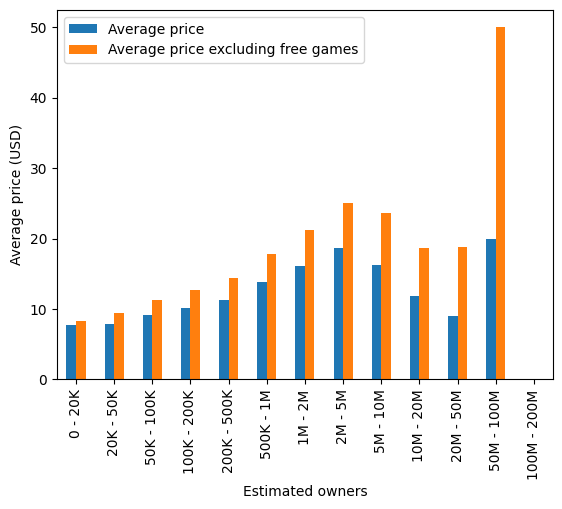

In [18]:
# Plot the average price by owners category
df_average_price.plot.bar(ylabel='Average price (USD)');

There is a trend that games with more owners have a higher price, up to 2M - 5M owners. Afterwards, it decreases until it shot back up for 50M - 100M owners. The one game with 100M - 200M owners is free.

The positive trend may be due to the fact that game studios will make the game more expensive if they know their game is going to sell a lot.
The dip at 5M - 50M owners may be present because the popularity of these games is partly due to their cheap price, and therefore more people can afford the game. It maybe that the game in the 2M - 5M owner category are of a similar quality than the games in the 20M - 50M category, but the difference in price is the reason they sold a different number of copies.

These correlations do not say that for a game to sell well, it needs to be at a certain price. However, the game should be priced according to the estimate number of copies sold.

## Reviews

Reviews can take several forms. It can be written or in a video format. However, for this analysis, it would be better to have reviews with numbers attached to it. As such, review score would be ideal. We see that there are two columns in the database that have scores: `'Metacritic score'` and `'User score'`. Both come from the well-known website Metacritic. The difference between the two is that the `'Metacritic score'` is an average of video-game critic score, while `'User score'` is from any player of the game.

In [19]:
# Look at the Metacritic scores
df['Metacritic score'].value_counts()

Metacritic score
0     85373
80      196
76      176
77      173
78      169
      ...  
24        1
20        1
33        1
23        1
8         1
Name: count, Length: 74, dtype: int64

In [20]:
# Look at the (Metacritic) user scores
df['User score'].value_counts()

User score
0      89317
100        5
80         2
84         2
46         2
94         2
51         2
95         2
68         2
77         2
96         1
87         1
66         1
76         1
98         1
88         1
82         1
83         1
73         1
92         1
71         1
78         1
61         1
60         1
63         1
55         1
65         1
53         1
97         1
69         1
57         1
59         1
70         1
Name: count, dtype: int64

There is a lot of 0s in the scores. This is probably not because the score is 0, but rather there is no score on Metacritic. I should not use these score because of the lack of information.

There is another option: the `'Positive'` and `'Negative'` counts, that comes directly from Steam.

In [21]:
# Find out how many low counts there are
df[['Positive', 'Negative']].value_counts().head(15)

Positive  Negative
0         0           15497
1         0            4453
2         0            2750
3         0            1874
0         1            1633
4         0            1415
1         1            1222
5         0            1055
2         1             976
6         0             793
3         1             710
4         1             635
7         0             609
1         2             553
5         1             530
Name: count, dtype: int64

This is better! However, we should still remove the games that have a low number of reviews. This is to prevent biases for a low number of reviews.
I will remove all games with less than 5 positive or 5 negatives.

Afterwards, I can calculate the fraction of positive reviews compared to the total reviews.

In [22]:
# Keeping only the games with more than 4 positives and 4 negative reviews
df_w_ratings = df[(df['Positive'] > 4) & (df['Negative'] > 4)][['Name', 'Estimated owners', 'Positive', 'Negative']]

# Calculating the fraction of positive reviews
df_w_ratings['Fraction positive'] = df_w_ratings['Positive'] / (df_w_ratings['Positive'] + df_w_ratings['Negative'])
df_w_ratings.head()

,Name,Estimated owners,Positive,Negative,Fraction positive
20200,Galactic Bowling,0 - 20K,6,11,0.352941
655370,Train Bandit,0 - 20K,53,5,0.913793
1139950,Two Weeks in Painland,0 - 20K,50,8,0.862069
1469160,Wartune Reborn,50K - 100K,87,49,0.639706
1659180,TD Worlds,0 - 20K,21,7,0.750000


In [23]:
# Finding the average of the fraction of positives for the different owners categories
df_rating_average = df_w_ratings.groupby('Estimated owners')['Fraction positive'].mean()
df_rating_average = df_rating_average.reindex(estimated_owners_order)

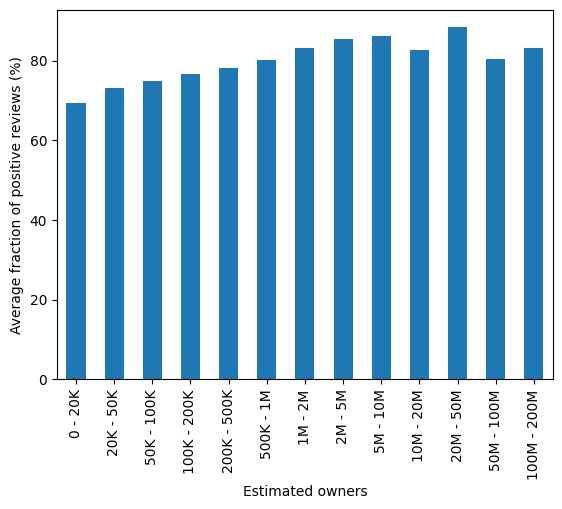

In [24]:
# Plot the average fraction of positives
(df_rating_average * 100).plot.bar(ylabel='Average fraction of positive reviews (%)');

There is correlation between the positive-review fraction and the number of owners. The games that have more owners have, in general, better reviews.
This makes sense, as a better game should sell more.

There is still a small hiccup in this conclusion. The positive review lower for games with 10M - 20M owners and above. This might be due to the type of games that these categories have. Free live-service games are popular. However, they usually have a player base that scrutinise every update for the game. They can easily lower the review score because of a single patch.

## Genres

A genre of a game is a category that describe its type of gameplay. These categories can be quite broad, and most games fall in more than one genre.
I will analyze the data to find out are the genres of the most popular games.

In [25]:
# Function that calculates the count of each genre in a dataframe
# df is the dataframe, to_df is if the return is a df (True) or a dictionary (False), df_column_name is the column name of the dataframe if to_df=True
def get_genre_count(df, to_df=False, df_column_name='Count'):
    genre_dict = {}
    for genres, number in df['Genres'].value_counts().items():
        for genre in genres.split(','):
            if genre not in genre_dict:
                genre_dict[genre] = number
            else:
                genre_dict[genre] += number
    if to_df:
        genre_df = pd.DataFrame.from_dict(genre_dict, orient='index')
        genre_df.columns = [df_column_name]
        return genre_df
    return genre_dict

In [26]:
# Create a DataFrame that contains the fraction of each genre for each owners category
genre_fraction_per_owner = pd.DataFrame()
for owners_category in estimated_owners_order:
    new_column = get_genre_count(df[df['Estimated owners'] == owners_category], to_df=True, df_column_name=owners_category) / len(df[df['Estimated owners'] == owners_category])
    genre_fraction_per_owner = pd.concat([genre_fraction_per_owner, new_column], axis=1)
genre_fraction_per_owner.fillna(0, inplace=True)
genre_fraction_per_owner

,0 - 20K,20K - 50K,50K - 100K,100K - 200K,200K - 500K,500K - 1M,1M - 2M,2M - 5M,5M - 10M,10M - 20M,20M - 50M,50M - 100M,100M - 200M
Casual,0.454377,0.355443,0.318092,0.278904,0.242067,0.180239,0.123810,0.098214,0.129032,0.105263,0.142857,0.0,0.0
Indie,0.718186,0.705690,0.663225,0.658408,0.609701,0.512486,0.379048,0.333333,0.290323,0.342105,0.380952,0.0,0.0
Action,0.400436,0.410294,0.420108,0.432432,0.479148,0.536374,0.590476,0.705357,0.688172,0.815789,0.857143,1.0,1.0
Adventure,0.386534,0.419113,0.405113,0.404655,0.393472,0.356135,0.354286,0.336310,0.344086,0.289474,0.428571,0.6,0.0
Strategy,0.179443,0.216504,0.235005,0.257883,0.266092,0.247557,0.245714,0.205357,0.161290,0.078947,0.000000,0.0,1.0
Simulation,0.203444,0.185454,0.212881,0.211712,0.223028,0.208469,0.200000,0.178571,0.139785,0.289474,0.095238,0.0,0.0
RPG,0.164943,0.214691,0.240413,0.233859,0.237534,0.274701,0.253333,0.250000,0.204301,0.263158,0.380952,0.4,0.0
Early Access,0.138407,0.108977,0.104474,0.094970,0.086129,0.078176,0.055238,0.056548,0.086022,0.078947,0.047619,0.0,0.0
Utilities,0.010284,0.006282,0.008358,0.011261,0.009066,0.006515,0.005714,0.000000,0.000000,0.000000,0.047619,0.0,0.0
Racing,0.037504,0.033708,0.036136,0.038664,0.046238,0.030402,0.030476,0.035714,0.000000,0.026316,0.000000,0.0,0.0


In [27]:
# Find the top 12 genres across all games
genre_fraction = get_genre_count(df, to_df=True) / len(df)
top_12_genres = genre_fraction.sort_values('Count', ascending=False)[:12].index
print(top_12_genres)

Index(['Indie', 'Casual', 'Action', 'Adventure', 'Simulation', 'Strategy',
       'RPG', 'Early Access', 'Sports', 'Free to Play', 'Racing',
       'Massively Multiplayer'],
      dtype='object')


In [28]:
# Only keep the top 12 genres and color the cells to see the trends
(genre_fraction_per_owner.loc[top_12_genres]*100).style.background_gradient(cmap='Blues', axis=None)

,0 - 20K,20K - 50K,50K - 100K,100K - 200K,200K - 500K,500K - 1M,1M - 2M,2M - 5M,5M - 10M,10M - 20M,20M - 50M,50M - 100M,100M - 200M
Indie,71.818648,70.569047,66.322517,65.840841,60.970082,51.248643,37.904762,33.333333,29.032258,34.210526,38.095238,0.000000,0.000000
Casual,45.437712,35.544279,31.809243,27.890390,24.206709,18.023887,12.380952,9.821429,12.903226,10.526316,14.285714,0.000000,0.000000
Action,40.043586,41.029358,42.010816,43.243243,47.914778,53.637351,59.047619,70.535714,68.817204,81.578947,85.714286,100.000000,100.000000
Adventure,38.653391,41.911321,40.511308,40.465465,39.347235,35.613464,35.428571,33.630952,34.408602,28.947368,42.857143,60.000000,0.000000
Simulation,20.344415,18.545367,21.288102,21.171171,22.302811,20.846906,20.000000,17.857143,13.978495,28.947368,9.523810,0.000000,0.000000
Strategy,17.944335,21.650356,23.500492,25.788288,26.609248,24.755700,24.571429,20.535714,16.129032,7.894737,0.000000,0.000000,100.000000
RPG,16.494317,21.469131,24.041298,23.385886,23.753400,27.470141,25.333333,25.000000,20.430108,26.315789,38.095238,40.000000,0.000000
Early Access,13.840697,10.897668,10.447394,9.496997,8.612874,7.817590,5.523810,5.654762,8.602151,7.894737,4.761905,0.000000,0.000000
Sports,4.704726,3.745318,3.982301,3.753754,4.623753,3.583062,4.190476,4.761905,5.376344,7.894737,0.000000,0.000000,0.000000
Free to Play,1.796143,9.689501,12.561455,13.551051,15.412511,16.829533,17.333333,19.940476,22.580645,28.947368,42.857143,60.000000,100.000000


The map above show the percentage of games in their respective owners category (top) that are of that genre (left). For example, a 20 in the intersection of `0 - 20K` and `Simulation` means that 20% of the games that have 0 and 20000 owners are simulation games.
Let's look at the genres one by one.

- Indie games are less common for games with a lot of owners. Unfortunately, the studio is indie and so it is impossible to get around this genre. Indie games can still be extremely popular.
- Casual games also have a negative correlation with the number of owners.
- Action games, on the other hand, have a positive correlation with the number of owners.
- Adventure games seem to be around 40% for all owners categories. There is a small negative correlation until 20M owners.
- Simulation games are pretty stable at around 20% for most categories, except for a drop-off for the games that have more than 20M owners.
- Strategy games seem to be somewhat stable between 20% and 25% until the 5M - 10M category where it starts dropping drops. It is interesting to see that the most popular game on steam is a strategy game.
- Role-playing games (RPGs) have a positive correlation with the number of owners.
- Early Access games have a negative correlation with the number of owners, but with a small increase for games between 5M and 20M owners.
- Sports games are between 3.5% to 5.5% for all categories except for 10M - 20M with a higher percentage (8%) and 20M+ games where no sports game are present.
- Free to Play games has a positive correlation, as evidenced by the Price section above.
- Racing games form between 3% and 5% of all owners categories of less than 5M owners. Only one games with more than 5M owners is a racing game (out of 158 games).
- Massively Multiplayer games has a positive correlation with the number of owners.

## Game description

Steam requires a description for all games on it platform.
Descriptions are crucial to tell the player what is the gameplay, art style, story, etc. of the game. These first impressions of a game can dictate the player's sentiment towards the game.
It is hard to find out what makes a good description with data. However, something we can look at is the length of these descriptions.

In the database, the game descriptions are in the `About the game` column.

In [29]:
# Create a dataframe with a column that is the number of words in the 'About the game' section
df_w_description = df[df['About the game'].notna()]
df_description_length = df_w_description['About the game'].transform(lambda x: len(x.split()))
df_description_length.name = 'Description length'
df_description_length = pd.concat([df_w_description[['Name', 'Estimated owners', 'About the game']], df_description_length], axis=1)
df_description_length.head()

,Name,Estimated owners,About the game,Description length
20200,Galactic Bowling,0 - 20K,Galactic Bowling is an exaggerated and stylize...,158
655370,Train Bandit,0 - 20K,THE LAW!! Looks to be a showdown atop a train....,87
1732930,Jolt Project,0 - 20K,Jolt Project: The army now has a new robotics ...,111
1355720,Henosis™,0 - 20K,HENOSIS™ is a mysterious 2D Platform Puzzler w...,92
1139950,Two Weeks in Painland,0 - 20K,ABOUT THE GAME Play as a hacker who has arrang...,115


In [30]:
# Looking at the games with the smallest description
df_description_length.sort_values('Description length').head(20)

,Name,Estimated owners,About the game,Description length
1332280,COVID-19 Epidemic Prevention,0 - 20K,通过酷鱼防疫宣传系列教学，用户可以避免去实体展馆带来的感染风险，只需要戴上VR设备就能真切地...,1
1700010,瀚辰书院,0 - 20K,瀚辰书院是一款养成文字休闲类游戏，游戏内收集各类物品，达成各种成就，每个成就都有独特的路线，...,1
1155860,MetalArms,0 - 20K,这是一款拥有多种玩法的VR游戏，精美的视效，爽快的手感，刺激的玩法，足以让您欲罢不能。,1
2603830,反击吧！NPC,20K - 50K,这是一款回合制RPG游戏，通过打怪升级，买装备变强，在RPG游戏中，通常勇者都能肆无忌惮的区...,1
109600,Neverwinter,5M - 10M,',1
842190,江湖侠客行,0 - 20K,江湖侠客行是一款武侠卡牌单机游戏，玩家在游戏中会学习到各种招式，以此来组建自己的武功套路同敌...,1
1704940,永生,0 - 20K,采用通常的MMO玩法。整个剧情是以未来人类探索永生为主题的游戏。在探索永生的道路上，遇到了很...,1
1417940,捕鱼炸翻天,20K - 50K,《捕鱼炸翻天》是一款以捕鱼为题材的4人同台真人竞技游戏。游戏场景丰富，每一个场次都有自己独特...,1
930840,东方百问~TouHouAsked,0 - 20K,Null,1
1658920,Crown Wars: The Black Prince,0 - 20K,/,1


It seems that descriptions with only one "word" are mostly in Chinese. Looking online, the others are games where the description is an image.
To remedy this, I will remove all games that have Chinese, Japanese or Korean (CJK) characters in the description.

In [31]:
# Code to check if a string has a character
# Code copied from Gemini AI
import re

def has_cjk_character(text):
    """
    Checks if a string contains any CJK character.
    """
    # Unicode ranges for common CJK characters (Simplified Chinese, Traditional Chinese, Japanese, Korean)
    # This pattern covers CJK Unified Ideographs, Hiragana, Katakana, Hangul Syllables, etc.
    cjk_pattern = re.compile(
        r'[\u4E00-\u9FFF\u3040-\u309F\u30A0-\u30FF\uAC00-\uD7AF]'
    )
    return bool(cjk_pattern.search(text))

In [32]:
# Remove the games that have at least a CJK character in their description.
df_description_length_wo_cjk = df_description_length[~df_description_length['About the game'].apply(has_cjk_character)]

# Look at the results
df_description_length_wo_cjk.sort_values('Description length').head(20)

,Name,Estimated owners,About the game,Description length
1658920,Crown Wars: The Black Prince,0 - 20K,/,1
109600,Neverwinter,5M - 10M,',1
930840,东方百问~TouHouAsked,0 - 20K,Null,1
1493800,Aircraft Carrier Survival: Tutorial,50K - 100K,/,1
342570,HIS (Heroes In the Sky),200K - 500K,-,1
2371310,Morphus,0 - 20K,Socials,1
1441010,The Pacifist's Great and Final Nightmare,0 - 20K,-,1
282960,The Sands Whisper Your Name,20K - 50K,Under Development,2
797660,God Test,0 - 20K,God Test,2
1792650,SpookyKillers: Chapter 1,0 - 20K,DISCORD &gt;&gt;&gt;,2


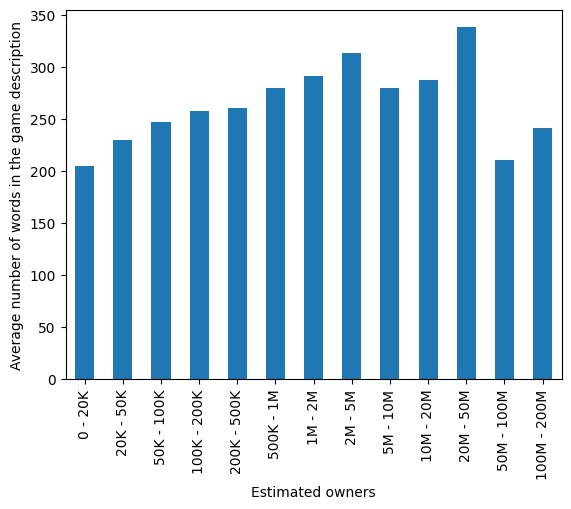

In [33]:
# Calculating the average of the number of words of the description for the different owner categories
df_description_length_average = df_description_length_wo_cjk.groupby('Estimated owners')['Description length'].mean()
df_description_length_average = df_description_length_average.reindex(estimated_owners_order)
df_description_length_average.plot.bar(ylabel='Average number of words in the game description');

There is a positive correlation between the description length and the number of owners until the number of owners reaches 2M - 5M. For more owners, the average length is more hectic and even decreases for the most owned games.

This initial increase tells us that a lengthy description is better than a smaller description. A longer description has a better chance of stating something that interests the player.

The decrease for games with the most owners might be caused by the reputation of the game that is already established. As such, the game description does not need to be expansive.

## Operating system support

Steam offers the possibility for games to support three operating systems: Windows, Mac and Linux.
We will explore the impact of supporting different operating systems on the popularity of a game.

In [34]:
# Looking at the number of games that support each system
systems = ['Windows', 'Mac', 'Linux']

for system in systems:
    print(df[system].value_counts())
    print()

Windows
True     89333
False       28
Name: count, dtype: int64

Mac
False    72086
True     17275
Name: count, dtype: int64

Linux
False    77272
True     12089
Name: count, dtype: int64



In [35]:
# Create a dataframe that contains the fraction of the games that are avaiable on Windows, Mac and Linux for each owners category
df_system_support = pd.DataFrame()
for system in systems:
    df_system_support[system] = df.groupby('Estimated owners')[system].mean()
    
df_system_support = df_system_support.reindex(estimated_owners_order)
df_system_support.head()

,Windows,Mac,Linux
Estimated owners,,,
0 - 20K,0.999672,0.166396,0.118708
20K - 50K,0.999879,0.255044,0.167210
50K - 100K,0.999017,0.280973,0.188545
100K - 200K,1.000000,0.329955,0.217342
200K - 500K,1.000000,0.355848,0.239347


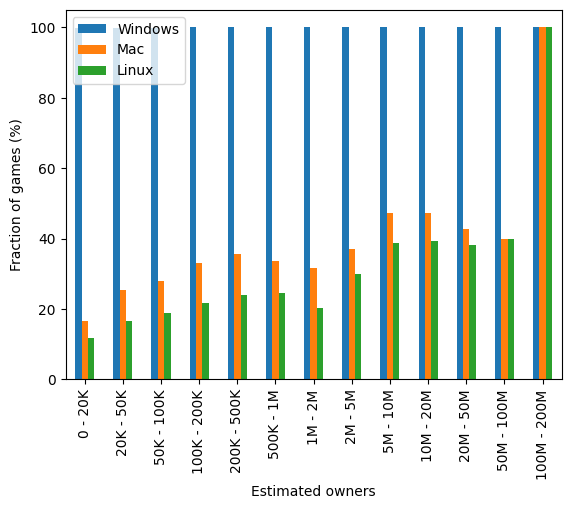

In [36]:
# Plot the operating system support (change it to percentage)
(df_system_support*100).plot.bar(ylabel='Fraction of games (%)');

Almost every game supports Windows.
As for Mac and Linux, there is a positive correlation between the number of games that support the platform and the number of owners.
The fraction of games for each category that support Mac and/or Linux never reaches more than 50%.

# Conclusions

Following this analysis, I would suggest the following actions to the game so that it has a better chance to be popular:

- Choose a popular genre. Action games and RPGs are more popular more than the rest. Adventure, simulation and strategy are somewhat popular too.
- Support multiple operating systems if possible. Supporting Windows is a must. Depending on the timeline and financial situation, Mac and Linux support should be considered. This is not necessary, most game do not support these operating systems.
- Create a good, captivating and appealing game. The reviews for this game will be better and the popularity of the game will follow.
- Write a complete game description. A lengthy description is better than a brief one.
- Choose a price according to the estimate number of sales. This should be done after the game is mostly done, and the studio is aware of the estimate number of buyers.

I note that these actions does not guarantee to increase a game's popularity, but they align with the trends seen throughout this analysis.